# Lab 1: Probability & Descriptive Statistics

## Instructions

Open in Google Colab: [Link](https://colab.research.google.com/drive/1JLABtp6OJUJHmODRHpQ9FQXovp73na_9?usp=share_link)

Alternatively, copy and paste the R code into RStudio Desktop and run it there.

Finish Quiz for Lab 1 on Canvas.

Focus: explore core descriptive statistics and dependence concepts using simple synthetic data.

🎯 In this lab, you will learn how to:

- Examine independence & correlation
- Compare skewed and roughly normal distributions
- Compute mean, variance, sd, skewness, kurtosis
- Compare biased vs unbiased variance estimators
- Simulate a high-correlation (ρ = 0.90) two-asset return setting
- Study sampling distributions of asset and portfolio means

## Datasets

Synthetic generators used:

- Right-skewed transaction values (log-normal)and approx. normal reference sample
- Two correlated asset return series (ρ = 0.90) for sampling exercises

Run each cell **sequentially**. Read the comments carefully.

In [1]:
# -------- Setup: packages --------
# Unified required package list
pkgs <- c("tidyverse", "data.table", "ggsci", "moments", "knitr", "kableExtra", "IRdisplay")
missing <- setdiff(pkgs, rownames(installed.packages()))
if (length(missing) > 0) install.packages(missing)

# Load all packages (silently)
invisible(lapply(pkgs, function(pkg) {
  suppressWarnings(suppressPackageStartupMessages(library(pkg, character.only = TRUE)))
}))

# Set default options for figures in Jupyter Notebook
options(repr.plot.width = 12, repr.plot.height = 4)  # wider default figures

message("\nSetup complete (packages loaded: ", paste(pkgs, collapse = ", "), ").")


Setup complete (packages loaded: tidyverse, data.table, ggsci, moments, knitr, kableExtra, IRdisplay).



In [2]:
#| label: chunk-opt
#| include: false
# set default chunk options
knitr::opts_chunk$set(echo = TRUE, message = FALSE, warning = FALSE, fig.align="center", fig.pos = "H", results="hold")
opts <- options(knitr.kable.NA = "")

## Independence vs. Zero Correlation

Independence means no influence between events, while correlation measures linear relationship strength. 

Independence implies zero correlation, but zero correlation does not imply independence.

E.g., $X$ and $Y = X^2$ have zero correlation but are NOT independent.

In [3]:
# ---- Zero Correlation but NOT Independence: Y = X^2 ----
# Idea: X ~ N(0,1); define Y = X^2. Then cor(X,Y) ~ 0 (symmetry cancels linear relation),
# yet Y is a deterministic function of X so they are NOT independent.

set.seed(2025)
n <- 5000
X <- rnorm(n)
Y <- X^2
r_xy <- cor(X, Y)
cat(sprintf("Sample correlation cor(X, Y=X^2) = %.4f (near 0)\n", r_xy))

Sample correlation cor(X, Y=X^2) = 0.0198 (near 0)


We got $\rho_{X,Y}=0.0198$. It seems to be close to zero, but we need a statistical test to confirm this formally. 

→ Test for significance of the correlation coefficient.

In [4]:
cor.test(X, Y)


	Pearson's product-moment correlation

data:  X and Y
t = 1.4027, df = 4998, p-value = 0.1608
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.007887062  0.047529726
sample estimates:
       cor 
0.01983657 


--------------------------------------------------------------------------------

💡 **Q: Based on the output of `cor.test`, what is the p-value for the correlation test? What can you conclude about the correlation between the two variables?** Are $X$ and $Y$ independent? Write your answer in the cell below.


A: [Type your answer here]

Distinguish the two expressions:

- There is no linear correlation. ❌
  
  We cannot say this because the Corr(X, Y) ≈ 0.02, which is not exactly zero. 

- There is no <span class="env-green">statistically significant</span> linear correlation. ✅
  
  This means there exists a linear correlation, but it is a weak one that is not statistically significant.

--------------------------------------------------------------------------------

Now let's visualize $Y=X^2$ by plotting the scatter plot.

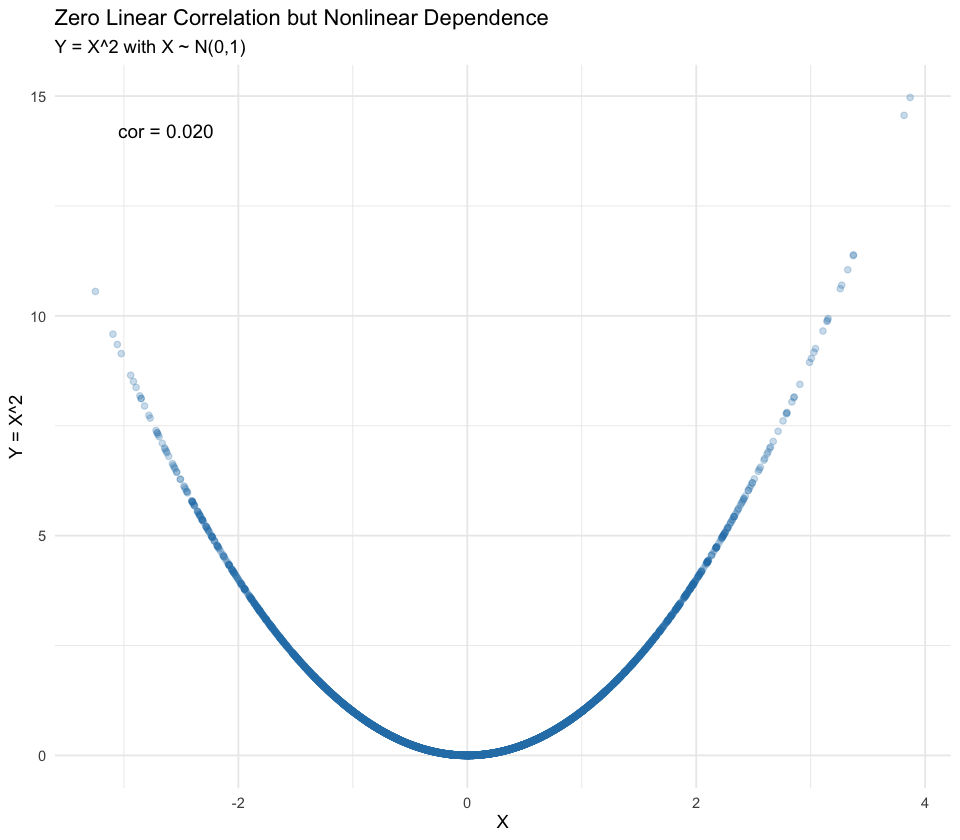

In [5]:
library(ggplot2)
options(repr.plot.width = 8, repr.plot.height = 7)
scatter_df <- data.frame(X = X, Y = Y)
p1 <- ggplot(scatter_df, aes(X, Y)) +
  geom_point(alpha = 0.25, color = '#2c7fb8') +
  annotate('text', x = min(X)+0.2, y = max(Y)*0.95,
           label = paste0('cor = ', sprintf('%.3f', r_xy)),
           hjust = 0, size = 4) +
  labs(title = 'Zero Linear Correlation but Nonlinear Dependence',
       subtitle = 'Y = X^2 with X ~ N(0,1)',
       x = 'X', y = 'Y = X^2') +
  theme_minimal()
print(p1)

The following figure shows the scatter plot of two assets with various correlation coefficients.

![correlation_varying_rho](images/correlation_varying_rho.png){width=100%}

## Descriptive Statistics on Asset Returns

In [6]:
# ---- Load Asset Returns Data ----
asset_df <- read_csv("https://raw.githubusercontent.com/my1396/FIN5005-Fall2025/refs/heads/main/data/asset_returns.csv")
print("Preview: first 6 rows of asset returns data frame:")
head(asset_df) %>% round(2)

Rows: 10000 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): Asset_A, Asset_B, Asset_C



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Preview: first 6 rows of asset returns data frame:"


Asset_A,Asset_B,Asset_C
<dbl>,<dbl>,<dbl>
17.89,4.31,9.94
10.30,4.17,10.55
20.87,14.16,6.61
18.21,22.33,9.58
17.49,2.23,10.23
29.87,15.72,8.97


We define a summary statistics function to compute the statistics of interest.

In [7]:
quick_summary <- function(x) {
  # Function to compute basic descriptive statistics
  data.frame(
    n = length(x),
    mean = mean(x),
    sd = sd(x),
    var = var(x),
    skewness = moments::skewness(x),
    kurtosis = moments::kurtosis(x),
    row.names = NULL
  )
}

The summary statistic table is generated as follows:

In [8]:
results <- lapply(asset_df, quick_summary) %>%
    do.call(rbind, .) %>%
    kable(format = "html", digits = 2, caption = "Descriptive Statistics of Asset Returns")
display_html(as.character(results)) 

,n,mean,sd,var,skewness,kurtosis
Asset_A,10000,20.14,4.82,23.24,-0.10,3.15
Asset_B,10000,8.50,4.44,19.71,1.71,9.19
Asset_C,10000,9.99,1.01,1.01,-0.85,3.50


Plot the histograms of the asset returns to visualize their distributions.

In [9]:
# ---- Visualization: Histograms with Normal Density Overlay ----
# Convert to long form
combined <- asset_df %>% pivot_longer(cols = everything(), names_to = "type", values_to = "value")

# Compute per-type mean & sd and create normal curve points
norm_params <- combined %>% group_by(type) %>% summarise(mu = mean(value), sigma = sd(value), .groups = 'drop')

norm_curve <- norm_params %>% group_by(type) %>% do({
  mu <- .$mu; sigma <- .$sigma
  x <- seq(mu - 4*sigma, mu + 4*sigma, length.out = 400)
  tibble(value = x, density = dnorm(x, mu, sigma))
})

p <- ggplot(combined, aes(value)) +
  geom_histogram(aes(y = after_stat(density)), bins = 40, fill = "#3182bd", alpha = 0.8, color = "white") +
  geom_line(data = norm_curve, aes(value, density), color = "red", linewidth = 0.8) +
  facet_wrap(~ type, scales = "free", nrow = 1) +
  labs(title = "Distribution Contrast with Normal Overlay",
       subtitle = "Red curve = fitted normal using sample mean & sd per asset",
       x = "Value", y = "Density") +
  theme_bw(base_size = 16) +
  theme(panel.spacing.x = unit(1.2, "lines"))

# Save the plot to a file
f_name <- "images/asset_returns_histograms.png"
if (!dir.exists("images")) dir.create("images")
ggsave(f_name, p, width = 15, height = 6)

::: {.content-visible when-format="html"}
::: {.scroll-img}
![](images/asset_returns_histograms.png){width=120%}
:::
:::

::: {.content-visible when-format="pdf"}
![](images/asset_returns_histograms.png){width=100%}
:::

--------------------------------------------------------------------------------

💡 **Q: Answer the following questions based on the summary statistics and the distribution plots:**

- Which asset has the highest mean return?
- Which asset is the most risky? And which one has the most stable returns?
- Which asset shows positive skewness and what does it mean?
- If an investor prefers assets with low risk and return distributions with tails close to normal, which asset is most appropriate?
- Based on mean and standard deviation, which asset has the best risk–return trade-off (highest mean per unit of risk)?


A: [Type your answer here]


---

## Large Sample Gives More Accurate Estimates

We have a variable $X \sim N(0, 25),$ that is, $X$ is from a normal distribution with mean 0 and variance 25.

Normal distribution notation: $X\sim N(\mu, \sigma^2)$ means that $X$ is normally distributed with mean $\mu$ and variance $\sigma^2.$

Note: The second parameter is the variance, <span class="env-orange">**NOT**</span> the standard deviation.

Now we draw random samples of size 5, 10, 10, ... until 5000 from this distribution and compute the sample mean and standard deviation for each sample.

For each sample, we compute the biased and unbiased sample variance

- The biased sample variance is computed as $$\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2.$$
- The unbiased sample variance is computed as $$\frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$$

In [10]:
# ---- Simulation: Sample vs Population variance ----
set.seed(2025)  # for reproducibility
true_var <- 25  # sd^2 with sd=5, true population variance
sample_sizes <- c(5, 10, 20, 50, 100, 250, 500, 1000, 5000) # varying sample sizes from 5 to 500
results <- lapply(sample_sizes, function(n){
  x <- rnorm(n, mean = 0, sd = 5)
  data.frame("sample_size" = n, "var_biased" = mean((x - mean(x))^2), "var_unbiased" = var(x))
}) %>% dplyr::bind_rows()
cat('Variance estimators: var_n (biased, divide by n) vs var_n1 (unbiased, divide by n-1).\n')
results

Variance estimators: var_n (biased, divide by n) vs var_n1 (unbiased, divide by n-1).


sample_size,var_biased,var_unbiased
<dbl>,<dbl>,<dbl>
5,4.262707,5.328384
10,14.832929,16.481032
20,33.210505,34.958426
50,25.332410,25.849398
100,24.957059,25.209150
250,22.936725,23.028840
500,25.862610,25.914439
1000,25.574182,25.599782
5000,25.301658,25.306719


--------------------------------------------------------------------------------

💡 **Q: Based on the variance estimates for different sample sizes:**

- **As the sample size increases, how do the sample variance estimates compare to the true variance $25$?**
- **Does the sample variance converge to the true variance as the sample size increases?**
- **How does the difference between the biased and unbiased sample variance estimators change as sample size increases?**

A: [Type your answer here]

--------------------------------------------------------------------------------

The figure below shows the how the sample variance estimates change as the sample size increases. 
The true (population) variance is 25, shown as the horizontal dashed line. The blue line is the biased sample variance and the orange line is the unbiased sample variance.

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


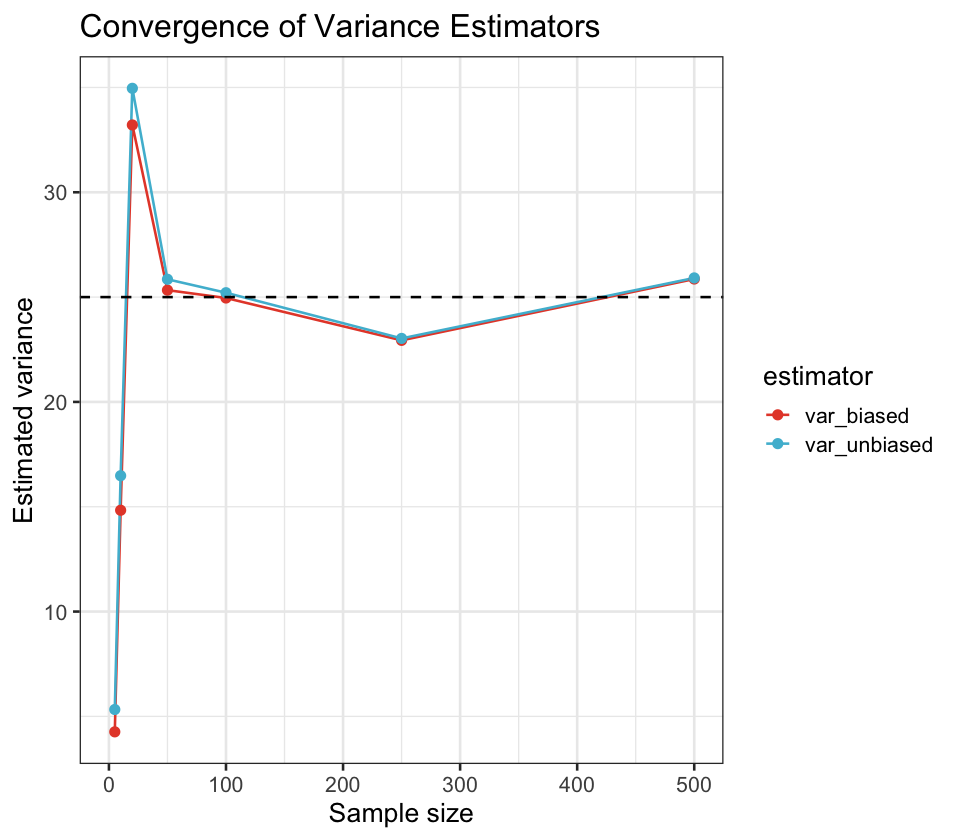

In [11]:
#| fig-dpi: 600
#| out-width: "80%"
#| fig-width: 9
#| fig-height: 6
#| warning: false

# ---- Plot: Convergence of variance estimators ----

results_long <- results %>%
  tidyr::pivot_longer(var_biased:var_unbiased, names_to = "estimator", values_to = "value") %>%
  dplyr::mutate(estimator = dplyr::recode(estimator, var_n = "Divide by n", var_n1 = "Divide by n-1"))

p <- ggplot(results_long, aes(sample_size, value, color = estimator)) +
  geom_line() +
  geom_point() +
  scale_color_npg() +
  geom_hline(yintercept = true_var, linetype = "dashed") +
  xlim(c(0,500)) +
  labs(title = "Convergence of Variance Estimators", y = "Estimated variance", x = "Sample size") +
  theme_bw(base_size = 16)
p


## Correlated Asset Returns

We will use 2,000 days of data on the returns of two (correlated) asset to examine the benfits of diversification.

You will first calculate the average volatility of the two assets and compare it with that of an equally weighted portfolio.

In [12]:
# ---- Load Correlated Asset Returns Data ----
X_demo <- read_csv("https://raw.githubusercontent.com/my1396/FIN5005-Fall2025/refs/heads/main/data/correlated_asset_returns.csv")
colnames(X_demo) <- c("Asset_A", "Asset_B")  # Rename columns for clarity
X_demo %>%
    as.data.table() %>%
    .[, lapply(.SD, function(x) if (is.numeric(x)) round(x, 4) else x)] %>%
    print(digits = 4)

Rows: 2000 Columns: 2


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): V1, V2



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


      Asset_A Asset_B
        <num>   <num>
   1:  0.0129  0.0351
   2:  0.0012  0.0094
   3:  0.0160  0.0130
   4:  0.0259  0.0550
   5:  0.0079  0.0147
  ---                
1996:  0.0080  0.0177
1997:  0.0061 -0.0001
1998: -0.0299 -0.0425
1999: -0.0202 -0.0357
2000:  0.0603  0.0746


In [13]:
emp_cor <- cor(X_demo)
emp_cor

,Asset_A,Asset_B
Asset_A,1.0000000,0.9040318
Asset_B,0.9040318,1.0000000


Plot the scatter plot of the two asset returns to visualize their relationship.

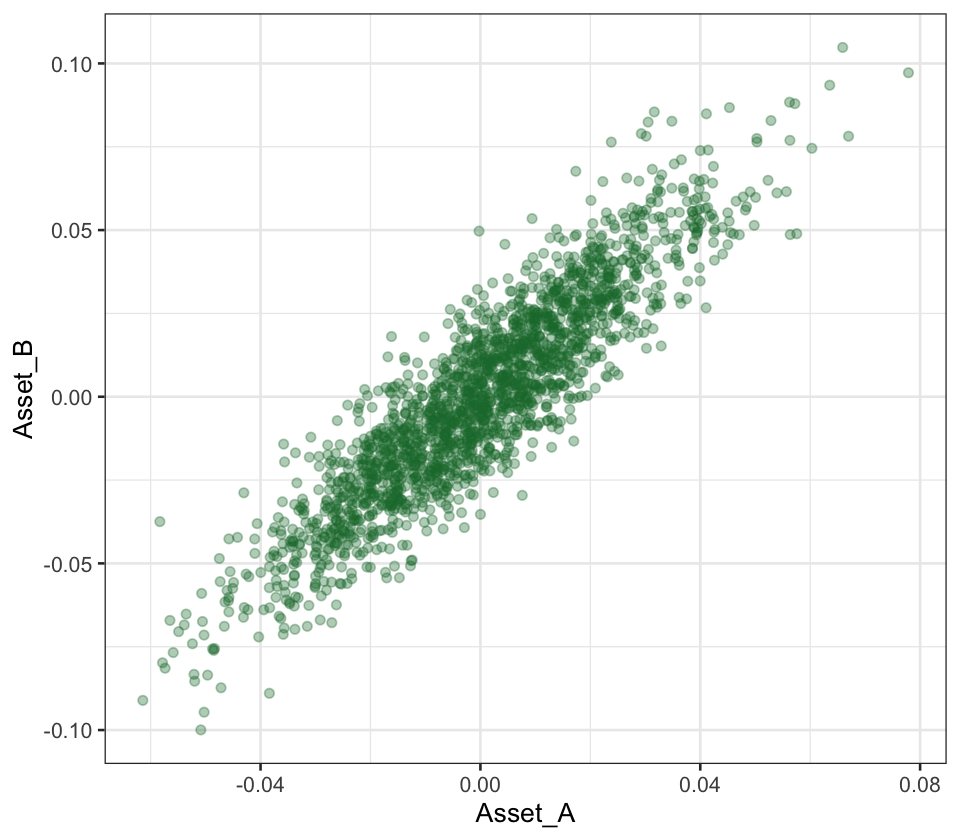

In [14]:
#| fig-dpi: 300
#| fig-width: 8
#| fig-height: 7
#| out-width: "70%"

options(repr.plot.width = 8, repr.plot.height = 7)
ggplot(X_demo, aes(Asset_A, Asset_B)) +
  geom_point(alpha = 0.35, color = '#1b7837') +
  theme_bw(base_size = 16)

--------------------------------------------------------------------------------

💡**Q: What is the correlation between the two asset returns? How do their prices move together?**

A: [Type your answer here]

--------------------------------------------------------------------------------

#### <span class="env-green"><i class="codicon codicon-rocket" style="font-size:2em; "></i>Practical Exercise</span>

Following the steps below, you will compute the mean and standard deviation of the two asset returns, construct a portfolio, and analyze its properties.

Step 1: Calculate the standard deviation of Asset A and B returns, respectively. 

Step 2: Construct a equally weighted portfolio of the two assets. Calculate the average portfolio returns.
$$
E[r_p] = \frac{1}{2} (E[r_A] + E[r_B])
$$

Step 3: Calculate the standard deviation of the portfolio returns, $\text{sd}(r_p)$.

Step 4: Calculate the average of the volatility of Asset A and B (using results in Step 1). Compare it with the volatility of the portfolio returns.

### Reflection

How does correlation between assets influence the portfolio mean's variability? Write 3–4 sentences interpreting for a diversified vs concentrated investment decision.